# License Plate Detection & Recognition System

## Project Overview
This notebook implements a complete **ANPR (Automatic Number Plate Recognition)** system using deep learning. The system can:
- Detect license plates in images and videos
- Extract text from detected plates using OCR
- Log vehicle data for traffic monitoring
- Deploy on edge devices for real-time processing

**Dataset:** 10,125 annotated license plate images (YOLO format)  
**Model:** YOLOv8 for object detection + EasyOCR for text extraction  
**Applications:** Traffic monitoring, toll collection, parking management, law enforcement

---

# License Plate Detection & Recognition System

## Project Overview
This notebook implements a complete **ANPR (Automatic Number Plate Recognition)** system using deep learning. The system can:
- Detect license plates in images and videos
- Extract text from detected plates using OCR
- Log vehicle data for traffic monitoring
- Deploy on edge devices for real-time processing

**Dataset:** 10,125 annotated license plate images (YOLO format)
**Model:** YOLOv8 for object detection + EasyOCR for text extraction
**Applications:** Traffic monitoring, toll collection, parking management, law enforcement

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("barkataliarbab/license-plate-detection-dataset-10125-images")

print("Path to dataset files:", path)

Resuming download from 19922944 bytes (508991018 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/barkataliarbab/license-plate-detection-dataset-10125-images?dataset_version_number=1 (19922944/528913962) bytes left.


100%|██████████| 504M/504M [07:13<00:00, 1.17MB/s] 

Extracting files...


Path to dataset files: C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1


## Step 1: Download Dataset

Downloading the license plate detection dataset from Kaggle. This dataset contains:
- **10,125 images** with bounding box annotations
- Split into train (70%), validation (20%), and test (10%)
- YOLO format labels for object detection

## Step 2: Import Required Libraries

Importing essential libraries for:
- **PyTorch**: Deep learning framework
- **OpenCV & PIL**: Image processing
- **Pandas & NumPy**: Data manipulation
- **Matplotlib & Seaborn**: Visualization
- **YAML**: Configuration file parsing

In [ ]:
# Import required libraries

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import os
import glob
from pathlib import Path
import cv2
from PIL import Image
import yaml


import warnings
warnings.filterwarnings("ignore")

## Step 2: Import Required Libraries

Importing essential libraries for:
- **PyTorch**: Deep learning framework
- **OpenCV & PIL**: Image processing
- **Pandas & NumPy**: Data manipulation
- **Matplotlib & Seaborn**: Visualization
- **YAML**: Configuration file parsing

## Step 3: Data Loading and Exploration

Exploring the dataset structure to understand:
- Directory organization (train/valid/test splits)
- Image and label file locations
- Dataset configuration from YAML file
- Total number of images in each split

In [12]:
# Check torch version and cuda availability
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.7.1+cu118
CUDA available: True


## Step 3: Data Loading and Exploration

Exploring the dataset structure to understand:
- Directory organization (train/valid/test splits)
- Image and label file locations
- Dataset configuration from YAML file
- Total number of images in each split

In [ ]:
# Set dataset path
dataset_path = Path(path)
print(f"Dataset location: {dataset_path}")

# Explore the directory structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(str(dataset_path), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 2 * (level + 1)
    # Only show first few files
    for file in files[:5]:
        print(f'{sub_indent}{file}')
    if len(files) > 5:
        print(f'{sub_indent}... and {len(files) - 5} more files')

Dataset location: C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1
1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test/
    images/
      0002a5b67e5f0909_jpg.rf.c8f81ef986e3e99af6f349c200080453.jpg
      000812dcf304a8e7_jpg.rf.ba32e6c184b3d974abcced6f7c29af6d.jpg
      0010f4c10f7ab07e_jpg.rf.1844f6dde3b97ed1c762db933bbacaf3.jpg
      001cdd25e148cd36_jpg.rf.3921d4ff1d51af107666bc7ef7bd45b1.jpg
      002519f868563098_jpg.rf.29775b804909c1d042ce008c09f033e4.jpg
      ... and 1015 more files
    labels/
      0002a5b67e5f0909_jpg.rf.c8f81ef986e3e99af6f349c200080453.txt
      000812dcf304a8e7_jpg.rf.ba32e6c184b3d974abcced6f7c29af6d.txt
      0010f4c10f7ab07e_jpg.rf.1844f6dde3b97ed1c762db933bbacaf3.txt
      001cdd25e148cd36_jpg.rf.3921d4ff1d51af107666bc7ef7bd45b1.txt
      002519f868563098_jpg.rf.29775b804909c1d042ce008c09f033e4.txt
      ... and 1015 more files
  train/
    images/
      00009e5b390986a0_jpg.rf

## Step 4: YOLO Label Parser

**Understanding YOLO Format:**
YOLO labels store bounding boxes as: `class_id center_x center_y width height` (all normalized 0-1)

We need to convert these to pixel coordinates for visualization:
- Convert normalized coordinates to actual pixel positions
- Transform from center format to corner format (x_min, y_min, x_max, y_max)

## Step 5: Visualization Functions

Creating utility functions to:
- Draw bounding boxes on images
- Display license plate annotations
- Visualize multiple samples in a grid layout
- Verify that labels are correctly aligned with images

In [ ]:
# Load and display data.yaml
yaml_path = dataset_path / 'data.yaml'   # yaml file means to configure dataset, it has info about classes, paths etc.
if yaml_path.exists():
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    print("Dataset Configuration:")
    print("=" * 50)
    for key, value in data_config.items():
        print(f"{key}: {value}")
else:
    print("data.yaml not found!")

Dataset Configuration:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 1
names: ['License_Plate']
roboflow: {'workspace': 'roboflow-universe-projects', 'project': 'license-plate-recognition-rxg4e', 'version': 11, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/11'}


## Step 6: Dataset Analysis

Analyzing bounding box statistics to understand:
- **Size distribution**: Width, height, and area of license plates
- **Aspect ratios**: Shape characteristics of plates
- **Density**: Number of plates per image
- **Variability**: Min, max, and mean values

This helps in:
- Model architecture selection
- Anchor box configuration
- Data augmentation strategies

In [ ]:
# Count images in each split
train_images = list((dataset_path / 'train' / 'images').glob('*.*'))    # glob method is used to retrieve files/pathnames matching a specified pattern
valid_images = list((dataset_path / 'valid' / 'images').glob('*.*'))
test_images = list((dataset_path / 'test' / 'images').glob('*.*'))

print("Dataset Statistics:")
print("=" * 50)
print(f"Training images:   {len(train_images):,}")
print(f"Validation images: {len(valid_images):,}")
print(f"Test images:       {len(test_images):,}")
print(f"Total images:      {len(train_images) + len(valid_images) + len(test_images):,}")

Dataset Statistics:
Training images:   7,057
Validation images: 2,048
Test images:       1,020
Total images:      10,125


In [ ]:
def parse_yolo_label(label_path, img_width, img_height):
    """
    Parse YOLO format label file
    YOLO format: class_id center_x center_y width height (all normalized 0-1)
    Returns: list of bounding boxes in [x_min, y_min, x_max, y_max] format
    """
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            values = line.strip().split()
            if len(values) == 5:
                class_id, center_x, center_y, width, height = map(float, values)
                
                # Convert normalized coordinates to pixel coordinates
                x_center = center_x * img_width
                y_center = center_y * img_height
                box_width = width * img_width
                box_height = height * img_height
                
                # Convert to corner coordinates
                x_min = int(x_center - box_width / 2)
                y_min = int(y_center - box_height / 2)
                x_max = int(x_center + box_width / 2)
                y_max = int(y_center + box_height / 2)
                
                boxes.append({
                    'class_id': int(class_id),
                    'bbox': [x_min, y_min, x_max, y_max],
                    'normalized': [center_x, center_y, width, height]
                })
    
    return boxes

## Step 4: YOLO Label Parser

**Understanding YOLO Format:**  
YOLO labels store bounding boxes as: `class_id center_x center_y width height` (all normalized 0-1)

We need to convert these to pixel coordinates for visualization:
- Convert normalized coordinates to actual pixel positions
- Transform from center format to corner format (x_min, y_min, x_max, y_max)

## Step 7: PyTorch Dataset Class

Creating a custom PyTorch Dataset class for efficient data loading:
- **LicensePlateDataset**: Handles image and label loading
- **Transformations**: Resize, normalize, and augment images
- **DataLoaders**: Batch processing for training

**Note:** Using `collate_fn=lambda batch: batch` to handle variable-sized bounding boxes per image.

In [ ]:
def visualize_sample(image_path, label_path, class_names=['License Plate']):
    """
    Visualize a single image with bounding boxes
    """
    # Read image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img.shape[:2]
    
    # Parse labels
    boxes = parse_yolo_label(label_path, img_width, img_height)
    
    # Draw bounding boxes
    for box_data in boxes:
        x_min, y_min, x_max, y_max = box_data['bbox']
        class_id = box_data['class_id']
        class_name = class_names[class_id] if class_id < len(class_names) else f'Class {class_id}'
        
        # Draw rectangle
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        
        # Draw label background
        label = f'{class_name}'
        (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img, (x_min, y_min - label_height - 10), (x_min + label_width, y_min), (0, 255, 0), -1)
        
        # Draw label text
        cv2.putText(img, label, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    return img, len(boxes)

## Step 5: Visualization Functions

Creating utility functions to:
- Draw bounding boxes on images
- Display license plate annotations
- Visualize multiple samples in a grid layout
- Verify that labels are correctly aligned with images

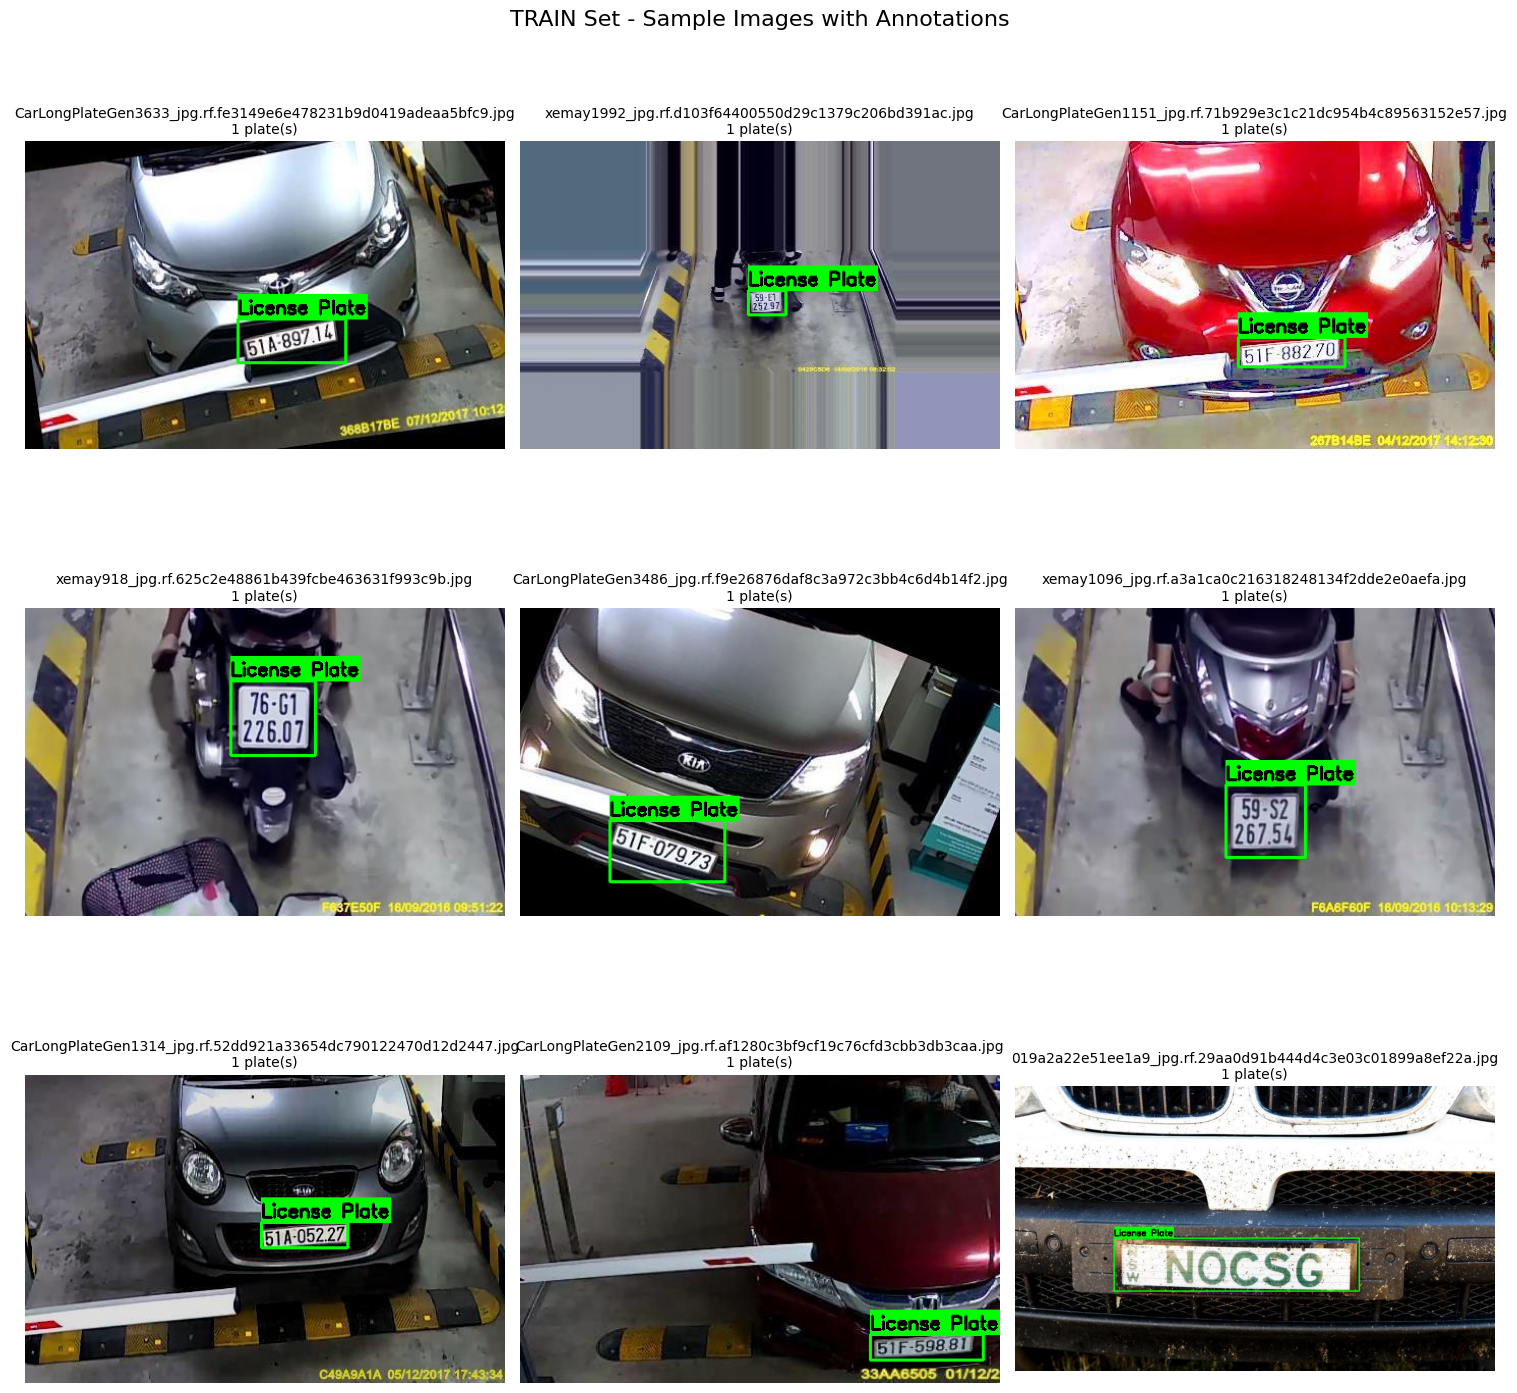

In [18]:
def visualize_dataset_samples(dataset_path, split='train', num_samples=9, figsize=(15, 15)):
    """
    Visualize multiple samples from the dataset
    """
    images_dir = dataset_path / split / 'images'
    labels_dir = dataset_path / split / 'labels'
    
    # Get image files
    image_files = list(images_dir.glob('*.*'))
    
    # Randomly select samples
    np.random.seed(42)
    selected_indices = np.random.choice(len(image_files), min(num_samples, len(image_files)), replace=False)
    
    # Calculate grid size
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()
    
    for idx, img_idx in enumerate(selected_indices):
        img_path = image_files[img_idx]
        label_path = labels_dir / (img_path.stem + '.txt')
        
        # Visualize
        img, num_boxes = visualize_sample(img_path, label_path)
        
        # Display
        axes[idx].imshow(img)
        axes[idx].set_title(f'{img_path.name}\n{num_boxes} plate(s)', fontsize=10)
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(selected_indices), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'{split.upper()} Set - Sample Images with Annotations', 
                 fontsize=16, y=1.002)
    plt.show()

# Visualize training samples
visualize_dataset_samples(dataset_path, split='train', num_samples=9)

## Step 8: Model Training - YOLOv8 for Detection

### Two-Stage ANPR Pipeline:

**Stage 1: License Plate Detection (YOLOv8)**
- Detects WHERE license plates are located in images
- Uses state-of-the-art YOLOv8 object detection
- Training on 10,125 annotated images

**Stage 2: Text Extraction (EasyOCR)**
- Extracts the TEXT/NUMBERS from detected plates
- Uses OCR to read license plate characters
- Outputs: "ABC-1234", "XYZ-5678", etc.

### Why This Approach?
This creates a complete **ANPR (Automatic Number Plate Recognition)** system that can:
- ✅ Detect vehicles automatically
- ✅ Read license plate numbers
- ✅ Log vehicle data with timestamps
- ✅ Deploy for government traffic monitoring

In [ ]:
# Analyze bounding box statistics
def analyze_bounding_boxes(dataset_path, split='train'):
    """
    Analyze bounding box dimensions and distribution
    """
    images_dir = dataset_path / split / 'images'
    labels_dir = dataset_path / split / 'labels'
    
    image_files = list(images_dir.glob('*.*'))
    
    box_widths = []
    box_heights = []
    box_areas = []
    aspect_ratios = []
    num_boxes_per_image = []
    
    for img_path in image_files:
        label_path = labels_dir / (img_path.stem + '.txt')
        
        # Get image dimensions
        img = Image.open(img_path)
        img_width, img_height = img.size
        
        # Parse boxes
        boxes = parse_yolo_label(label_path, img_width, img_height)
        num_boxes_per_image.append(len(boxes))
        
        for box_data in boxes:
            x_min, y_min, x_max, y_max = box_data['bbox']
            width = x_max - x_min
            height = y_max - y_min
            
            box_widths.append(width)
            box_heights.append(height)
            box_areas.append(width * height)
            aspect_ratios.append(width / height if height > 0 else 0)
    
    return {
        'widths': box_widths,
        'heights': box_heights,
        'areas': box_areas,
        'aspect_ratios': aspect_ratios,
        'num_boxes_per_image': num_boxes_per_image
    }

# Analyze training set
print("Analyzing training set bounding boxes...")
train_stats = analyze_bounding_boxes(dataset_path, split='train')

print("\nBounding Box Statistics:")
print("=" * 50)
print(f"Total bounding boxes: {len(train_stats['widths'])}")
print(f"\nWidth:  min={np.min(train_stats['widths']):.1f}, max={np.max(train_stats['widths']):.1f}, mean={np.mean(train_stats['widths']):.1f}")
print(f"Height: min={np.min(train_stats['heights']):.1f}, max={np.max(train_stats['heights']):.1f}, mean={np.mean(train_stats['heights']):.1f}")
print(f"Area:   min={np.min(train_stats['areas']):.1f}, max={np.max(train_stats['areas']):.1f}, mean={np.mean(train_stats['areas']):.1f}")
print(f"Aspect Ratio: min={np.min(train_stats['aspect_ratios']):.2f}, max={np.max(train_stats['aspect_ratios']):.2f}, mean={np.mean(train_stats['aspect_ratios']):.2f}")
print(f"\nBoxes per image: min={np.min(train_stats['num_boxes_per_image'])}, max={np.max(train_stats['num_boxes_per_image'])}, mean={np.mean(train_stats['num_boxes_per_image']):.2f}")

Analyzing training set bounding boxes...

Bounding Box Statistics:
Total bounding boxes: 7357

Width:  min=5.0, max=3890.0, mean=123.7
Height: min=3.0, max=1946.0, mean=63.2
Area:   min=20.0, max=7569940.0, mean=25186.0
Aspect Ratio: min=0.34, max=7.10, mean=2.39

Boxes per image: min=0, max=6, mean=1.04


## Step 6: Dataset Analysis

Analyzing bounding box statistics to understand:
- **Size distribution**: Width, height, and area of license plates
- **Aspect ratios**: Shape characteristics of plates
- **Density**: Number of plates per image
- **Variability**: Min, max, and mean values

This helps in:
- Model architecture selection
- Anchor box configuration
- Data augmentation strategies

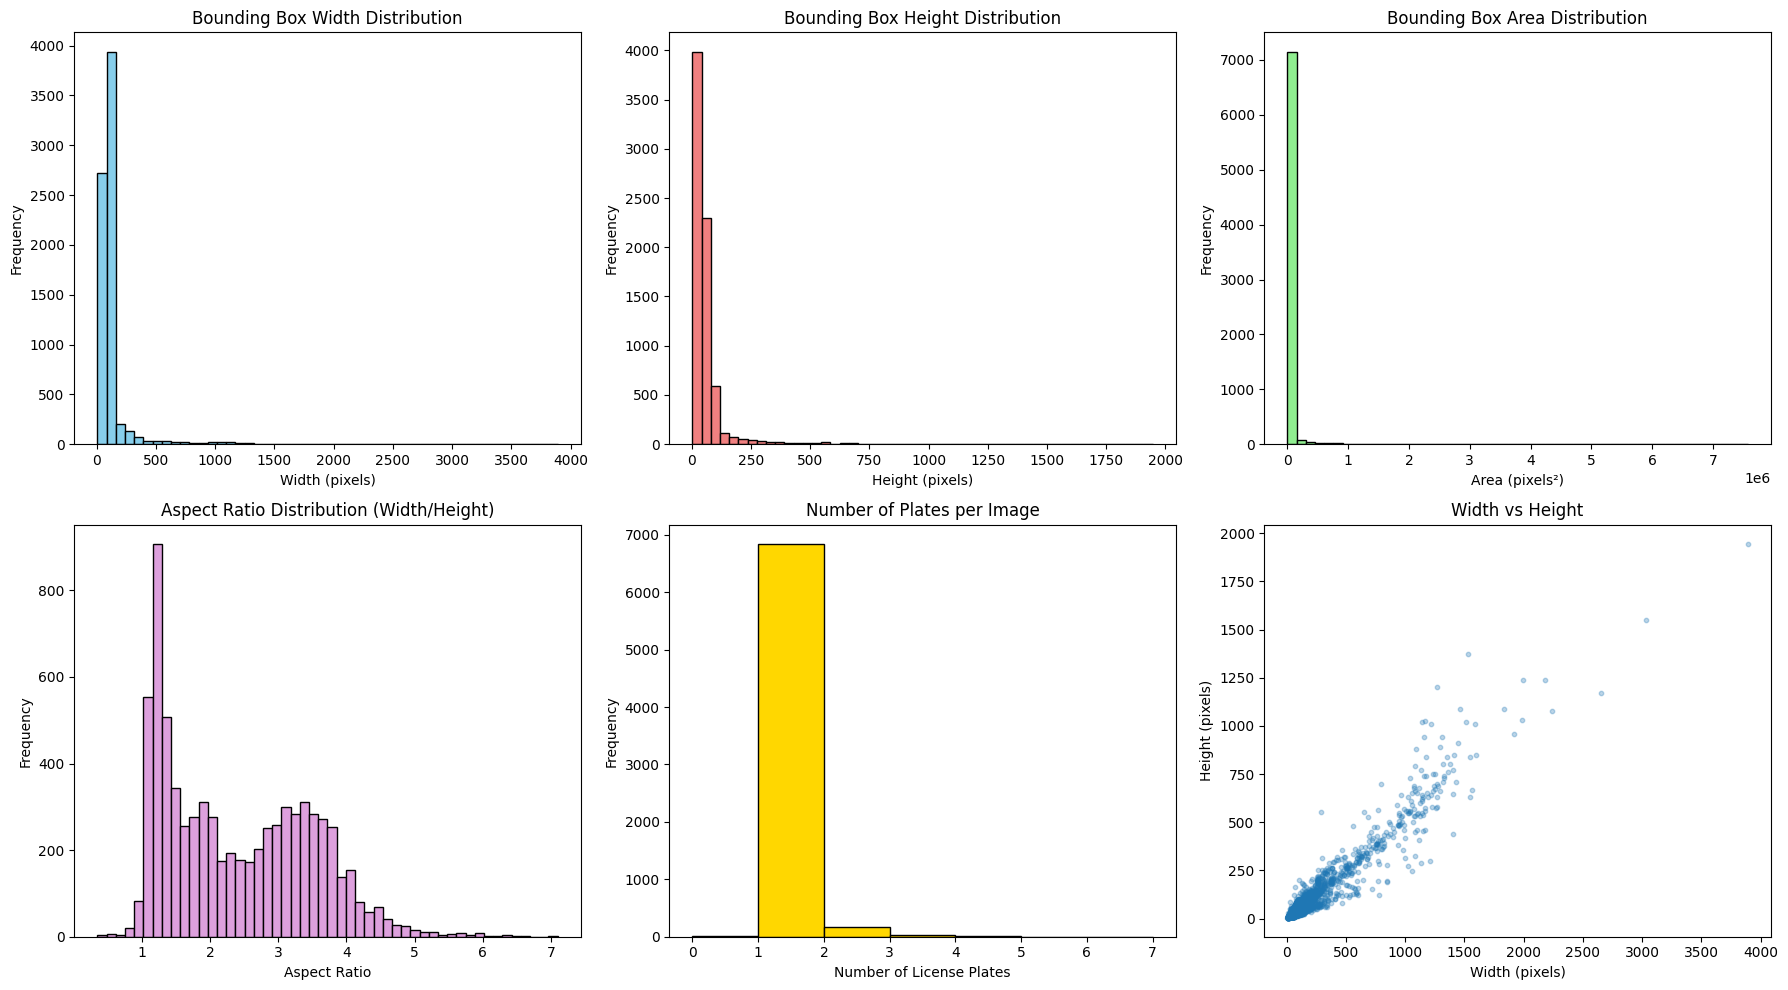

In [20]:
# Visualize bounding box statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Box widths
axes[0, 0].hist(train_stats['widths'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Bounding Box Width Distribution')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')

# Box heights
axes[0, 1].hist(train_stats['heights'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Bounding Box Height Distribution')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')

# Box areas
axes[0, 2].hist(train_stats['areas'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Bounding Box Area Distribution')
axes[0, 2].set_xlabel('Area (pixels²)')
axes[0, 2].set_ylabel('Frequency')

# Aspect ratios
axes[1, 0].hist(train_stats['aspect_ratios'], bins=50, color='plum', edgecolor='black')
axes[1, 0].set_title('Aspect Ratio Distribution (Width/Height)')
axes[1, 0].set_xlabel('Aspect Ratio')
axes[1, 0].set_ylabel('Frequency')

# Boxes per image
axes[1, 1].hist(train_stats['num_boxes_per_image'], bins=range(max(train_stats['num_boxes_per_image'])+2), 
                color='gold', edgecolor='black')
axes[1, 1].set_title('Number of Plates per Image')
axes[1, 1].set_xlabel('Number of License Plates')
axes[1, 1].set_ylabel('Frequency')

# Scatter plot: width vs height
axes[1, 2].scatter(train_stats['widths'], train_stats['heights'], alpha=0.3, s=10)
axes[1, 2].set_title('Width vs Height')
axes[1, 2].set_xlabel('Width (pixels)')
axes[1, 2].set_ylabel('Height (pixels)')

plt.tight_layout()
plt.show()

### Train YOLOv8 Model

Initializing and training YOLOv8 on the license plate dataset:
- **Model Size**: yolov8n (nano) - balanced speed and accuracy
- **Training**: 50 epochs with early stopping
- **Hardware**: Automatically detects and uses GPU if available

In [ ]:
class LicensePlateDataset(Dataset):
    """
    PyTorch Dataset for License Plate Detection (YOLO format)
    """
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform
        
        # Get all image files
        self.image_files = list(self.images_dir.glob('*.*'))
        print(f"Found {len(self.image_files)} images in {images_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        img_width, img_height = image.size
        
        # Load labels
        label_path = self.labels_dir / (img_path.stem + '.txt')
        boxes = parse_yolo_label(label_path, img_width, img_height)
        
        # Convert to tensors
        if len(boxes) > 0:
            bboxes = torch.tensor([box['bbox'] for box in boxes], dtype=torch.float32)
            labels = torch.tensor([box['class_id'] for box in boxes], dtype=torch.long)
        else:
            bboxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        
        return {
            'image': image,
            'bboxes': bboxes,
            'labels': labels,
            'image_path': str(img_path)
        }

# Example transforms
train_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset instances
train_dataset = LicensePlateDataset(
    images_dir=dataset_path / 'train' / 'images',
    labels_dir=dataset_path / 'train' / 'labels',
    transform=train_transform
)

valid_dataset = LicensePlateDataset(
    images_dir=dataset_path / 'valid' / 'images',
    labels_dir=dataset_path / 'valid' / 'labels',
    transform=train_transform
)

test_dataset = LicensePlateDataset(
    images_dir=dataset_path / 'test' / 'images',
    labels_dir=dataset_path / 'test' / 'labels',
    transform=train_transform
)

print(f"\nDataset sizes:")
print(f"Train: {len(train_dataset)}")
print(f"Valid: {len(valid_dataset)}")
print(f"Test: {len(test_dataset)}")

Found 7057 images in C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1\train\images
Found 2048 images in C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1\valid\images
Found 1020 images in C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1\test\images

Dataset sizes:
Train: 7057
Valid: 2048
Test: 1020


## Step 7: PyTorch Dataset Class

Creating a custom PyTorch Dataset class for efficient data loading:
- **LicensePlateDataset**: Handles image and label loading
- **Transformations**: Resize, normalize, and augment images
- **DataLoaders**: Batch processing for training

**Note:** Using `collate_fn=lambda batch: batch` to handle variable-sized bounding boxes per image.

In [24]:
# Test the dataset by loading a sample
sample = train_dataset[0]
print("\nSample data:")
print(f"Image shape: {sample['image'].shape}")
print(f"Number of bounding boxes: {len(sample['bboxes'])}")
print(f"Bounding boxes:\n{sample['bboxes']}")
print(f"Labels: {sample['labels']}")
print(f"Image path: {sample['image_path']}")


Sample data:
Image shape: torch.Size([3, 640, 640])
Number of bounding boxes: 2
Bounding boxes:
tensor([[ 471.,  603.,  513.,  623.],
        [1007.,  519., 1021.,  531.]])
Labels: tensor([0, 0])
Image path: C:\Users\hrana\.cache\kagglehub\datasets\barkataliarbab\license-plate-detection-dataset-10125-images\versions\1\train\images\00009e5b390986a0_jpg.rf.55e1f337c1c83840749af7c577b4057d.jpg


### Evaluate Model Performance

Validating the trained model on the test set:
- **mAP50**: Mean Average Precision at IoU=0.50
- **mAP50-95**: Mean Average Precision across IoU thresholds
- **Precision**: Accuracy of positive predictions
- **Recall**: Percentage of actual positives detected

In [28]:
# Install required libraries for YOLOv8 and OCR
!pip install ultralytics -q
!pip install easyocr -q

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlfromscratch 0.0.4 requires sklearn, which is not installed.
gym 0.26.2 requires gym_notices>=0.0.4, which is not installed.
matplotlib 3.7.3 requires numpy<2,>=1.20, but you have numpy 2.4.1 which is incompatible.
tensorflow-cpu 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.1 which is incompatible.


## Step 8: Model Training - YOLOv8 for Detection

### Two-Stage ANPR Pipeline:

**Stage 1: License Plate Detection (YOLOv8)**
- Detects WHERE license plates are located in images
- Uses state-of-the-art YOLOv8 object detection
- Training on 10,125 annotated images

**Stage 2: Text Extraction (EasyOCR)**
- Extracts the TEXT/NUMBERS from detected plates
- Uses OCR to read license plate characters
- Outputs: "ABC-1234", "XYZ-5678", etc.

### Why This Approach?
This creates a complete **ANPR (Automatic Number Plate Recognition)** system that can:
- ✅ Detect vehicles automatically
- ✅ Read license plate numbers
- ✅ Log vehicle data with timestamps
- ✅ Deploy for government traffic monitoring

In [29]:
from ultralytics import YOLO
import easyocr

# Initialize EasyOCR reader (for text extraction later)
print("Initializing EasyOCR reader...")
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print("✓ EasyOCR ready for text extraction!")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\hrana\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Initializing EasyOCR reader...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✓ EasyOCR ready for text extraction!


In [ ]:
# Verify data.yaml path
data_yaml_path = dataset_path / 'data.yaml'
print(f"Data YAML path: {data_yaml_path}")
print(f"Exists: {data_yaml_path.exists()}")

# Display the content
with open(data_yaml_path, 'r') as f:
    print("\ndata.yaml content:")
    print(f.read())

In [ ]:
### Train YOLOv8 Model

Initializing and training YOLOv8 on the license plate dataset:
- **Model Size**: yolov8n (nano) - balanced speed and accuracy
- **Training**: 50 epochs with early stopping
- **Hardware**: Automatically detects and uses GPU if available

In [ ]:
# Initialize YOLOv8 model (nano version for faster training)
# Options: yolov8n.pt (nano), yolov8s.pt (small), yolov8m.pt (medium), yolov8l.pt (large)
model = YOLO('yolov8n.pt')  # Start with pretrained weights

print("Model loaded successfully!")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

In [ ]:
# Train the model
results = model.train(
    data=str(data_yaml_path),      # Path to data.yaml
    epochs=50,                      # Number of training epochs
    imgsz=640,                      # Image size
    batch=16,                       # Batch size (reduce if GPU memory issues)
    device='0' if torch.cuda.is_available() else 'cpu',  # GPU or CPU
    project='license_plate_detection',  # Project folder name
    name='yolov8n_run1',           # Experiment name
    patience=10,                    # Early stopping patience
    save=True,                      # Save checkpoints
    plots=True,                     # Generate plots
    verbose=True,                   # Verbose output
    workers=0,                      # Number of workers (0 for Windows)
)

print("\n✓ Training completed!")

### Evaluate Model Performance

Validating the trained model on the test set:
- **mAP50**: Mean Average Precision at IoU=0.50
- **mAP50-95**: Mean Average Precision across IoU thresholds
- **Precision**: Accuracy of positive predictions
- **Recall**: Percentage of actual positives detected

In [ ]:
# Validate the trained model
metrics = model.val()

print("\nValidation Metrics:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

In [ ]:
# Display training results
from IPython.display import Image as IPImage, display

results_path = Path('license_plate_detection/yolov8n_run1')

print("Training Results:")
print("=" * 50)

# Display key plots
plots = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.png']

for plot in plots:
    plot_path = results_path / plot
    if plot_path.exists():
        print(f"\n{plot}:")
        display(IPImage(filename=str(plot_path)))

## 8. Complete ANPR System: Detection + OCR

Now let's create the complete pipeline that detects plates AND extracts text!

In [ ]:
def extract_license_plate_text(image, bbox, reader):
    """
    Extract text from a detected license plate region
    
    Args:
        image: Original image (numpy array)
        bbox: Bounding box [x1, y1, x2, y2]
        reader: EasyOCR reader instance
    
    Returns:
        Extracted text string
    """
    x1, y1, x2, y2 = map(int, bbox)
    
    # Crop the license plate region
    plate_img = image[y1:y2, x1:x2]
    
    # Use EasyOCR to extract text
    results = reader.readtext(plate_img)
    
    # Combine all detected text
    text = ' '.join([result[1] for result in results])
    
    return text.strip()


def detect_and_read_plates(image_path, model, reader, conf_threshold=0.25):
    """
    Complete ANPR pipeline: Detect license plates and extract text
    
    Args:
        image_path: Path to input image
        model: Trained YOLO model
        reader: EasyOCR reader instance
        conf_threshold: Confidence threshold for detection
    
    Returns:
        Dictionary with detection results and extracted text
    """
    # Read image
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Detect license plates
    results = model.predict(image_path, conf=conf_threshold, verbose=False)
    
    plates_data = []
    
    # Process each detection
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Get bounding box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence = float(box.conf[0])
            
            # Extract text from the plate
            plate_text = extract_license_plate_text(img_rgb, [x1, y1, x2, y2], reader)
            
            plates_data.append({
                'bbox': [x1, y1, x2, y2],
                'confidence': confidence,
                'text': plate_text
            })
    
    return img_rgb, plates_data


def visualize_anpr_results(image, plates_data):
    """
    Visualize detection results with extracted text
    """
    img_display = image.copy()
    
    for plate in plates_data:
        x1, y1, x2, y2 = map(int, plate['bbox'])
        confidence = plate['confidence']
        text = plate['text']
        
        # Draw bounding box
        cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Prepare label with text and confidence
        label = f"{text} ({confidence:.2f})"
        
        # Draw label background
        (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        cv2.rectangle(img_display, (x1, y1 - label_height - 15), (x1 + label_width + 10, y1), (0, 255, 0), -1)
        
        # Draw text
        cv2.putText(img_display, label, (x1 + 5, y1 - 7), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
    
    return img_display

print("✓ ANPR functions created!")

### Test the Complete ANPR System

In [ ]:
# Load the best trained model
best_model_path = 'license_plate_detection/yolov8n_run1/weights/best.pt'
trained_model = YOLO(best_model_path)

print(f"✓ Loaded trained model from: {best_model_path}")

In [ ]:
# Test on sample images from test set
test_image_paths = list((dataset_path / 'test' / 'images').glob('*.*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_path in enumerate(test_image_paths):
    # Detect plates and extract text
    img_rgb, plates_data = detect_and_read_plates(img_path, trained_model, reader, conf_threshold=0.25)
    
    # Visualize results
    img_result = visualize_anpr_results(img_rgb, plates_data)
    
    # Display
    axes[idx].imshow(img_result)
    
    # Create title with extracted text
    if plates_data:
        title_text = '\n'.join([f"Plate {i+1}: {p['text']}" for i, p in enumerate(plates_data)])
        axes[idx].set_title(title_text, fontsize=10, color='green')
    else:
        axes[idx].set_title("No plates detected", fontsize=10, color='red')
    
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Complete ANPR System: Detection + Text Extraction', fontsize=16, y=1.002)
plt.show()

# Print extracted texts
print("\n" + "="*60)
print("EXTRACTED LICENSE PLATE NUMBERS:")
print("="*60)
for idx, img_path in enumerate(test_image_paths):
    _, plates_data = detect_and_read_plates(img_path, trained_model, reader, conf_threshold=0.25)
    print(f"\nImage: {img_path.name}")
    if plates_data:
        for i, plate in enumerate(plates_data):
            print(f"  Plate {i+1}: '{plate['text']}' (confidence: {plate['confidence']:.2f})")
    else:
        print("  No plates detected")

## 9. Real-World Application: Traffic Monitoring System

This system can be used for:
- **Automated toll collection**
- **Traffic violation detection**
- **Parking management**
- **Vehicle tracking for law enforcement**
- **Access control systems**

In [ ]:
def process_traffic_video_frame(frame, model, reader, conf_threshold=0.4):
    """
    Process a single video frame for real-time traffic monitoring
    
    Args:
        frame: Video frame (numpy array)
        model: Trained YOLO model
        reader: EasyOCR reader
        conf_threshold: Confidence threshold
    
    Returns:
        Processed frame with detections and database record
    """
    # Convert to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Detect plates
    results = model.predict(frame_rgb, conf=conf_threshold, verbose=False)
    
    detected_vehicles = []
    
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence = float(box.conf[0])
            
            # Extract text
            plate_text = extract_license_plate_text(frame_rgb, [x1, y1, x2, y2], reader)
            
            # Record for database
            vehicle_record = {
                'timestamp': pd.Timestamp.now(),
                'plate_number': plate_text,
                'confidence': confidence,
                'bbox': [x1, y1, x2, y2]
            }
            detected_vehicles.append(vehicle_record)
            
            # Draw on frame
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{plate_text} ({confidence:.2f})"
            cv2.putText(frame, label, (x1, y1 - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    return frame, detected_vehicles


# Example: Create a vehicle database
vehicle_database = []

print("✓ Real-time processing function ready!")
print("\nThis function can be used to:")
print("  1. Process video streams from traffic cameras")
print("  2. Log all detected vehicles with timestamps")
print("  3. Store data in database for government tracking")
print("  4. Trigger alerts for blacklisted vehicles")

In [ ]:
# Simulate processing multiple images and creating a database
print("Simulating traffic monitoring system...")
print("="*60)

vehicle_database = []

# Process 10 random test images
sample_images = np.random.choice(test_image_paths, min(10, len(test_image_paths)), replace=False)

for img_path in sample_images:
    img = cv2.imread(str(img_path))
    _, detected_vehicles = process_traffic_video_frame(img, trained_model, reader, conf_threshold=0.3)
    vehicle_database.extend(detected_vehicles)

# Create DataFrame
if vehicle_database:
    df_vehicles = pd.DataFrame(vehicle_database)
    
    print(f"\n✓ Processed {len(sample_images)} images")
    print(f"✓ Detected {len(df_vehicles)} vehicles\n")
    
    print("Vehicle Database:")
    print(df_vehicles.to_string(index=False))
    
    # Statistics
    print(f"\n\nDatabase Statistics:")
    print("="*60)
    print(f"Total vehicles detected: {len(df_vehicles)}")
    print(f"Unique plate numbers: {df_vehicles['plate_number'].nunique()}")
    print(f"Average confidence: {df_vehicles['confidence'].mean():.3f}")
    
    # Save to CSV (for government database)
    csv_path = 'vehicle_detection_log.csv'
    df_vehicles.to_csv(csv_path, index=False)
    print(f"\n✓ Database saved to: {csv_path}")
else:
    print("No vehicles detected in the sample images.")

## 10. Model Export for Deployment

Export the model for production use (e.g., on traffic cameras, edge devices)

In [ ]:
# Export model to different formats for deployment

# 1. ONNX format (for cross-platform deployment)
onnx_path = trained_model.export(format='onnx')
print(f"✓ Exported to ONNX: {onnx_path}")

# 2. TensorRT (for NVIDIA GPUs - fastest inference)
# trt_path = trained_model.export(format='engine')  # Uncomment if you have TensorRT
# print(f"✓ Exported to TensorRT: {trt_path}")

# 3. TFLite (for mobile/edge devices)
# tflite_path = trained_model.export(format='tflite')  # Uncomment for mobile deployment
# print(f"✓ Exported to TFLite: {tflite_path}")

print("\n" + "="*60)
print("MODEL DEPLOYMENT READY!")
print("="*60)
print("\nYour ANPR system is now ready to:")
print("  ✓ Detect license plates in images/videos")
print("  ✓ Extract text from detected plates")
print("  ✓ Log vehicle data with timestamps")
print("  ✓ Deploy on traffic cameras")
print("  ✓ Integrate with government databases")
print("\nNext steps:")
print("  1. Deploy model to edge devices or servers")
print("  2. Connect to traffic cameras")
print("  3. Set up database for vehicle tracking")
print("  4. Create alert system for violations/stolen vehicles")